In [1]:
pip install qiskit-nature pyscf qiskit==1.4.5 qiskit-ibm-runtime qiskit-aer pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of qiskit-ibm-runtime to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 65.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 67.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.6/51.6 MB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 91.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 381.8/381.8 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 75.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━

In [10]:
import numpy as np
import pandas as pd

from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit

# Bond lengths in Angstrom
bond_lengths = np.linspace(0.25, 1.5, 21)

from qiskit_nature.second_q.mappers import JordanWignerMapper
mapper = JordanWignerMapper()

from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService(channel="ibm_quantum_platform",token="o0HHHmjs4XqpE1a8XStoNA1St_k1lzzoYx1LYxBgxnh-")
service.active_account()
print('Available backends:')
print(service.backends(simulator=False))
backend = service.least_busy(operational=True, simulator=False)
print(f"Backend = {backend.name}")

# We will start by using a local simulator
from qiskit_aer import AerSimulator

# Import an estimator, this time from qiskit (we will import from Runtime for real hardware)
from qiskit.primitives import BackendEstimatorV2

# generate a simulator that mimics the real quantum system
backend_sim = AerSimulator.from_backend(backend)
estimator = BackendEstimatorV2(backend=backend_sim)

from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD

num_spatial_orbitals = 2
num_particles = (1, 1)
ansatz = UCCSD(
    num_spatial_orbitals,
    num_particles,
    mapper,
    initial_state=HartreeFock(
        num_spatial_orbitals,
        num_particles,
        mapper,
    ),
)
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import SLSQP, COBYLA

from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from scipy.optimize import minimize

from qiskit.transpiler import PassManager
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
ansatz_isa = pm.run(ansatz)

from time import time


energies = []
ground_energies = []
optimizer_times = []
iteration_number = []
optimizer_results = []
nuclear_repulsion_energies = []


for r in bond_lengths:
    # Define H2 geometry
    geometry = f"H 0 0 0; H 0 0 {r}"

    # PySCF driver
    driver = PySCFDriver(
        atom=geometry,
        basis="sto3g",
        spin=0,
        charge=0,
        unit=DistanceUnit.ANGSTROM,
    )

    # Run electronic structure calculation
    problem = driver.run()
    nuclear_repulsion = problem.hamiltonian.nuclear_repulsion_energy



    vqe_solver = VQE(estimator, ansatz, COBYLA())
    vqe_solver.initial_point = [0.0] * ansatz.num_parameters
    x0 = vqe_solver.initial_point

    solver = GroundStateEigensolver(mapper, vqe_solver)

    main_operator, aux_ops = solver.get_qubit_operators(problem)

    H = main_operator
    hamiltonian_isa = H.apply_layout(ansatz_isa.layout)

    def cost_func(params, ansatz, H, estimator):
        pub = (ansatz, [H], [params])
        result = estimator.run(pubs=[pub]).result()
        energy = result[0].data.evs[0]
        return energy


    start_time = time()
    result = minimize(
        cost_func,
        x0,
        args=(ansatz_isa, hamiltonian_isa, estimator),
        method="cobyla",
        options={"maxiter": 50, "disp": True},)

    optimizer_time = time() - start_time
    energy = result.fun
    ground_state_energy = energy + nuclear_repulsion


    energies.append(energy)
    ground_energies.append(ground_state_energy)
    optimizer_results.append(result)
    optimizer_times.append(optimizer_time)
    nuclear_repulsion_energies.append(nuclear_repulsion)
    iteration_number.append(result.nfev)



# Create table
df = pd.DataFrame({
    "Bond Length (Å)": bond_lengths,
    "Results": optimizer_results,
    "Ground State Energy (Hartree)": ground_energies,
    "Time (s)": optimizer_times,
    "Nuclear Repulsion Energy (Hartree)": nuclear_repulsion_energies,
    "Electronic Energies (Hartree)": energies
})
print(df)


qiskit_runtime_service._discover_account:WARNING:2026-03-04 04:39:15,079: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-03-04 04:39:17,693: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-03-04 04:39:17,695: Loading instance: open-instance, plan: open


Available backends:
[<IBMBackend('ibm_fez')>, <IBMBackend('ibm_torino')>, <IBMBackend('ibm_marrakesh')>]


qiskit_runtime_service.backends:WARNING:2026-03-04 04:39:25,158: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-03-04 04:39:33,707: Using instance: open-instance, plan: open


Backend = ibm_torino


ERROR:stevedore.extension:Could not load 'ibm_backend': cannot import name 'calc_final_ops' from 'qiskit.transpiler.passes.utils.remove_final_measurements' (/usr/local/lib/python3.12/dist-packages/qiskit/transpiler/passes/utils/remove_final_measurements.py)
ERROR:stevedore.extension:Could not load 'ibm_dynamic_and_fractional': cannot import name 'calc_final_ops' from 'qiskit.transpiler.passes.utils.remove_final_measurements' (/usr/local/lib/python3.12/dist-packages/qiskit/transpiler/passes/utils/remove_final_measurements.py)
ERROR:stevedore.extension:Could not load 'ibm_dynamic_circuits': cannot import name 'calc_final_ops' from 'qiskit.transpiler.passes.utils.remove_final_measurements' (/usr/local/lib/python3.12/dist-packages/qiskit/transpiler/passes/utils/remove_final_measurements.py)
ERROR:stevedore.extension:Could not load 'ibm_fractional': cannot import name 'calc_final_ops' from 'qiskit.transpiler.passes.utils.remove_final_measurements' (/usr/local/lib/python3.12/dist-packages/qi

Return from COBYLA because the trust region radius reaches its lower bound.
Number of function values = 30   Least value of F = -2.079689782941861
The corresponding X is:
[0. 0. 0.]

Return from COBYLA because the trust region radius reaches its lower bound.
Number of function values = 39   Least value of F = -2.029187481534929
The corresponding X is:
[ 0.03166297  0.06917629 -0.04506964]

Return from COBYLA because the trust region radius reaches its lower bound.
Number of function values = 31   Least value of F = -1.9663567634818881
The corresponding X is:
[-0.08491884 -0.01616067 -0.05289742]

Return from COBYLA because the trust region radius reaches its lower bound.
Number of function values = 38   Least value of F = -1.9149681070881095
The corresponding X is:
[ 0.05537651  0.0721662  -0.06405975]

Return from COBYLA because the trust region radius reaches its lower bound.
Number of function values = 33   Least value of F = -1.856414282508376
The corresponding X is:
[ 0.06188424  

In [11]:
df.to_pickle("Results_AerSimulator_PEC_H2_Molecule.pkl")

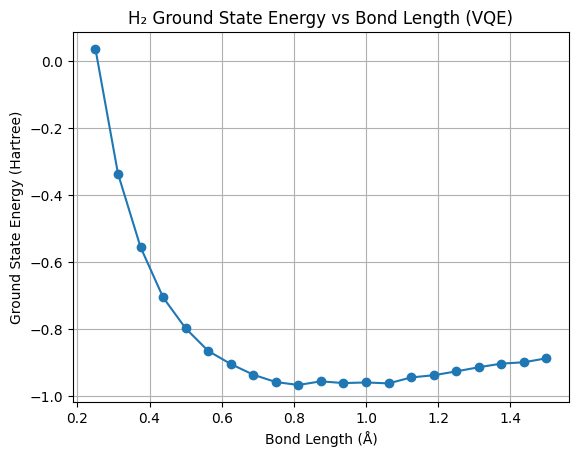

In [12]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(df["Bond Length (Å)"], df["Ground State Energy (Hartree)"], marker='o')

plt.xlabel("Bond Length (Å)")
plt.ylabel("Ground State Energy (Hartree)")
plt.title("H₂ Ground State Energy vs Bond Length (VQE)")
plt.grid(True)

plt.show()

In [13]:
plt.savefig("h2_vqe_energy_curve.png")

<Figure size 640x480 with 0 Axes>

In [14]:
print(df[["Bond Length (Å)", "Ground State Energy (Hartree)"]])

    Bond Length (Å)  Ground State Energy (Hartree)
0            0.2500                       0.037019
1            0.3125                      -0.335820
2            0.3750                      -0.555218
3            0.4375                      -0.705420
4            0.5000                      -0.798060
5            0.5625                      -0.865453
6            0.6250                      -0.904549
7            0.6875                      -0.936593
8            0.7500                      -0.958530
9            0.8125                      -0.967276
10           0.8750                      -0.956404
11           0.9375                      -0.961655
12           1.0000                      -0.959773
13           1.0625                      -0.962531
14           1.1250                      -0.944796
15           1.1875                      -0.938204
16           1.2500                      -0.926692
17           1.3125                      -0.914343
18           1.3750            